In [166]:
import sys

import torch as th
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torch.utils.data import random_split
from torch.utils.data import TensorDataset

from neuralop.models import FNO, GINO
from neuralop import H1Loss

from tqdm.auto import tqdm
# from neuralop import Trainer
# from neuralop.data.datasets import load_darcy_flow_small

device = 'cuda' if th.cuda.is_available() else 'cpu'

In [49]:
def rasterize(mesh_coordinates, permeability, solution):
    x = mesh_coordinates[0, :, 0]
    y = mesh_coordinates[0, :, 1]

    x_unique = np.sort(np.unique(x))
    y_unique = np.sort(np.unique(y))

    perm_2d = np.zeros((65, 65))
    sol2d = np.zeros((65, 65))

    for i in range(len(x)):
        col_idx = np.searchsorted(x_unique, x[i])
        row_idx = np.searchsorted(y_unique, y[i])
        perm_2d[row_idx, col_idx] = permeability[i]
        sol2d[row_idx, col_idx] = solution[i]

    return perm_2d, sol2d


In [172]:
lfno = FNO(n_modes=(128, 128),
             in_channels=1, 
             out_channels=1,
             hidden_channels=32, 
             projection_channel_ratio=2)

In [173]:
mesh_coordinates = np.load("darcy_flow_training_data/mesh_coordinates.npy")[None]
mesh_connectivity = np.load("darcy_flow_training_data/cells.npy")
permeability = np.load("darcy_flow_training_data/permeability.npy")
solution = np.load("darcy_flow_training_data/solution.npy")

permeability_data, solution_data = [], []

for p, s in tqdm(zip(permeability, solution)):
    p2d, s2d = rasterize(mesh_coordinates, p, s)
    permeability_data.append(p2d)
    solution_data.append(s2d)


permeability = th.tensor(np.array(permeability_data), dtype=th.float32)[:, None]
solution = th.tensor(np.array(solution_data), dtype=th.float32)[:, None]


dataset = TensorDataset(permeability, solution)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

0it [00:00, ?it/s]

1000it [00:19, 52.22it/s]


In [174]:
optimizer = th.optim.AdamW(
    lfno.parameters(), 
    lr=8e-3, 
    weight_decay=1e-4
)
scheduler = th.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
h1loss = H1Loss(d=2)

In [175]:
%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [176]:
%autoreload
lfno = lfno.to(device)


for epoch in tqdm(range(100), file=sys.stdout):
    lfno.train()
    for batch in train_loader:
        optimizer.zero_grad()
        p, s = batch
        p, s = p.to(device), s.to(device)
        s_pred = lfno(p)
        loss = h1loss(s_pred, s)
        loss.backward()
        optimizer.step()
    scheduler.step()

    lfno.eval()
    test_loss = 0
    for batch in test_loader:
        p, s = batch
        p, s = p.to(device), s.to(device)
        s_pred = lfno(p)
        test_loss += h1loss(s_pred, s).item()
    tqdm.write(f"Epoch {epoch} Test Loss: {test_loss / len(test_loader)}")

    

Epoch 0 Test Loss: 7.563660110746111   
Epoch 1 Test Loss: 4.500498362949917           
Epoch 2 Test Loss: 4.029738886015756           
Epoch 3 Test Loss: 3.4843938520976474          
Epoch 4 Test Loss: 3.491724669933319           
Epoch 5 Test Loss: 3.386942412172045           
Epoch 6 Test Loss: 3.120688966342381           
Epoch 7 Test Loss: 3.404746873038156           
Epoch 8 Test Loss: 3.1689412082944597          
Epoch 9 Test Loss: 2.9621370009013583          
Epoch 10 Test Loss: 2.870872919048582           
Epoch 11 Test Loss: 2.8690472160066878          
Epoch 12 Test Loss: 2.8066283805029735          
Epoch 13 Test Loss: 2.7000438272953033          
Epoch 14 Test Loss: 2.755447498389653           
Epoch 15 Test Loss: 2.7646772861480713          
Epoch 16 Test Loss: 2.6690296019826616          
Epoch 17 Test Loss: 2.728987148829869           
Epoch 18 Test Loss: 2.6361120087759837          
Epoch 19 Test Loss: 2.6323464257376537          
Epoch 20 Test Loss: 2.5817491241863797

Text(0.5, 1.0, 'Difference')

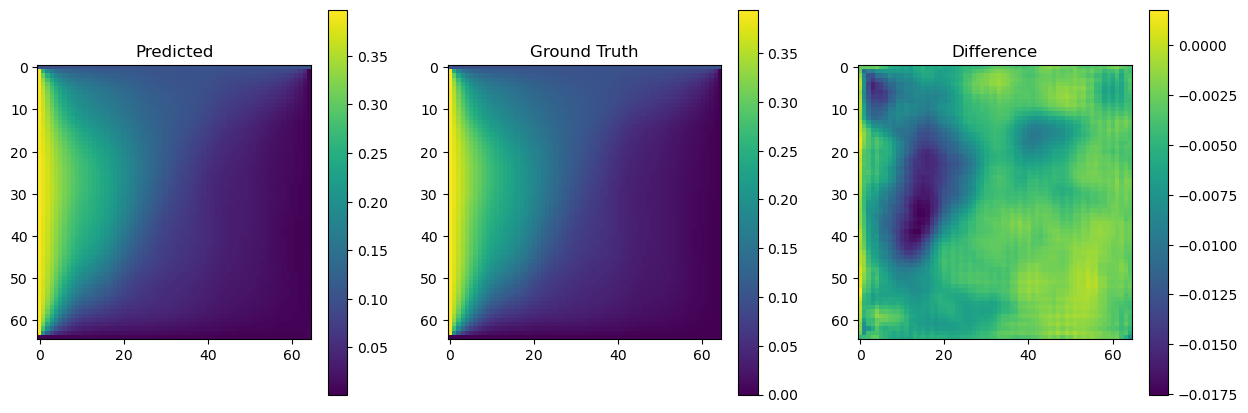

In [177]:
lfno.to('cpu')

i = 6
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(lfno(test_dataset[i][0][None]).detach().numpy().squeeze())
plt.colorbar()
plt.title('Predicted')

plt.subplot(1, 3, 2)
plt.imshow(test_dataset[i][1].numpy().squeeze())
plt.colorbar()
plt.title('Ground Truth')

plt.subplot(1, 3, 3)
plt.imshow(test_dataset[i][1].numpy().squeeze() - lfno(test_dataset[i][0][None]).detach().numpy().squeeze())
plt.colorbar()
plt.title('Difference')

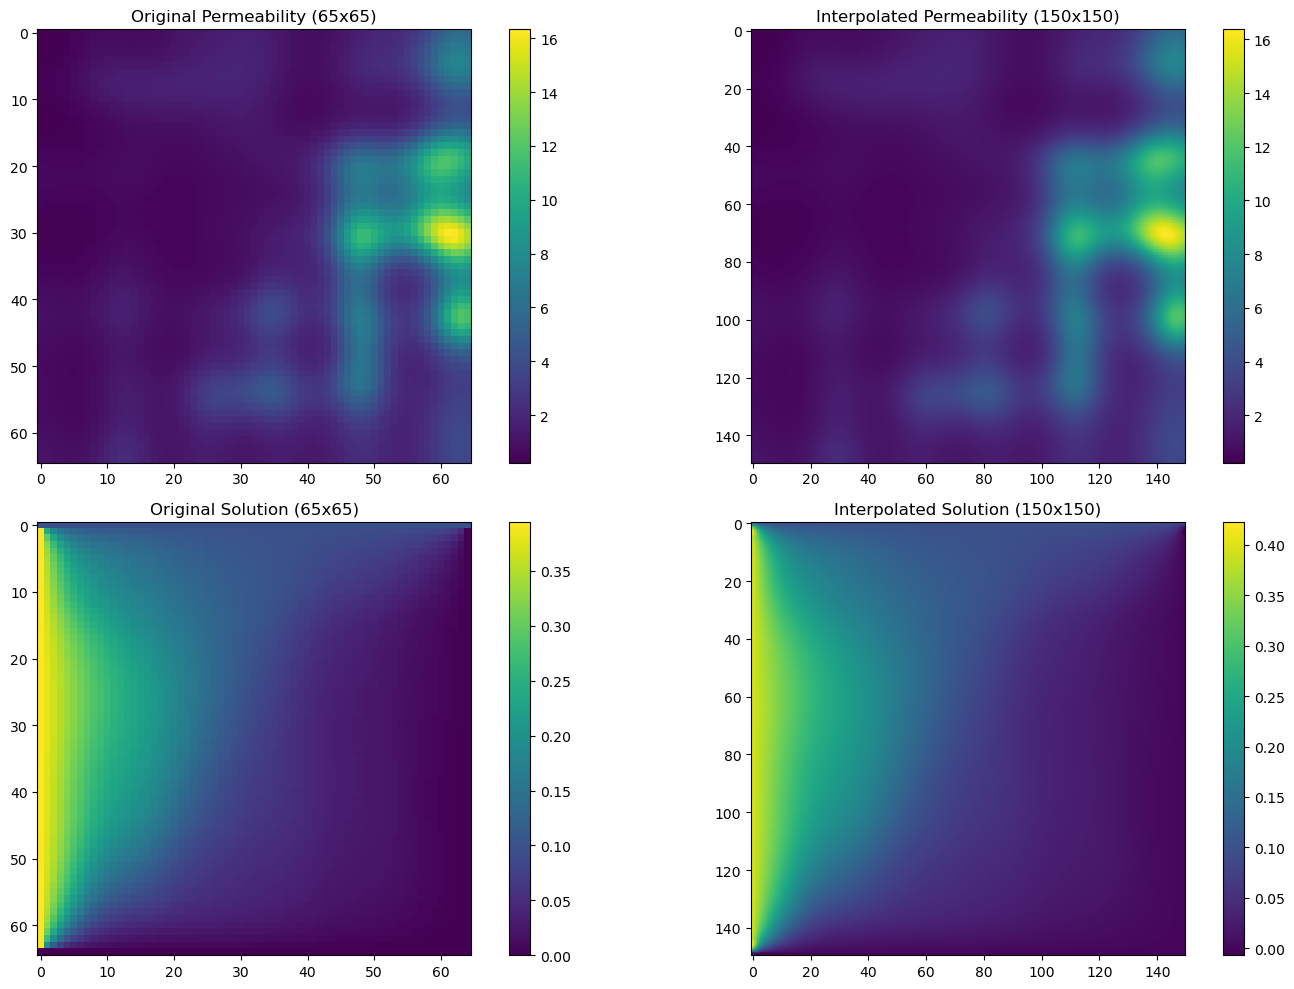

In [178]:
from scipy.interpolate import griddata
import numpy as np

# Get a test sample
i = 6  # Same index as used in the visualization cell
test_sample_perm = test_dataset[i][0].numpy().squeeze()
test_sample_sol = test_dataset[i][1].numpy().squeeze()

# Create original grid points
x_orig = np.linspace(0, 1, 65)
y_orig = np.linspace(0, 1, 65)
X_orig, Y_orig = np.meshgrid(x_orig, y_orig)

# Create new grid points with higher resolution
x_new = np.linspace(0, 1, 150)
y_new = np.linspace(0, 1, 150)
X_new, Y_new = np.meshgrid(x_new, y_new)

# Reshape the original points and values for interpolation
points = np.column_stack((X_orig.flatten(), Y_orig.flatten()))
values_perm = test_sample_perm.flatten()
values_sol = test_sample_sol.flatten()

# Interpolate
perm_highres = griddata(points, values_perm, (X_new, Y_new), method='cubic')
sol_highres = griddata(points, values_sol, (X_new, Y_new), method='cubic')

# Plot the results
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(test_sample_perm)
plt.colorbar()
plt.title('Original Permeability (65x65)')

plt.subplot(2, 2, 2)
plt.imshow(perm_highres)
plt.colorbar()
plt.title('Interpolated Permeability (150x150)')

plt.subplot(2, 2, 3)
plt.imshow(test_sample_sol)
plt.colorbar()
plt.title('Original Solution (65x65)')

plt.subplot(2, 2, 4)
plt.imshow(sol_highres)
plt.colorbar()
plt.title('Interpolated Solution (150x150)')

plt.tight_layout()

Text(0.5, 1.0, 'Difference')

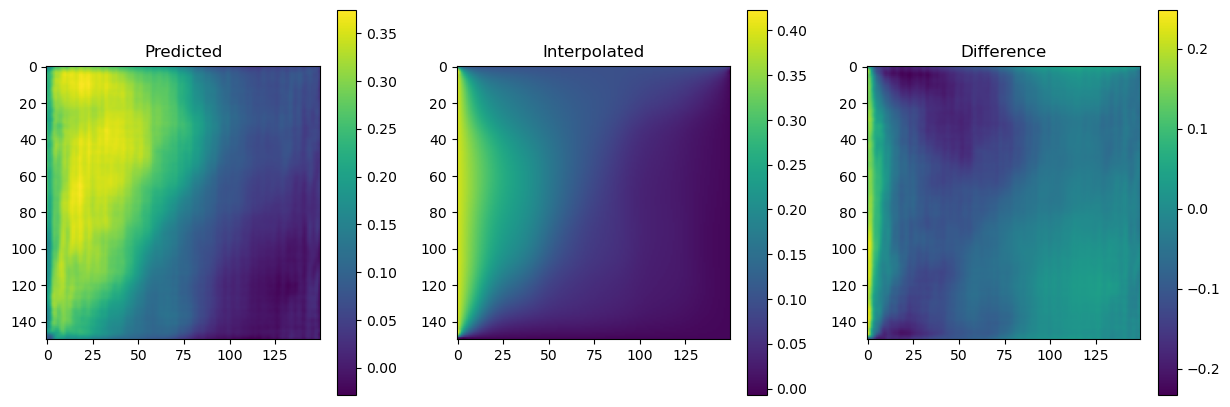

In [180]:
from numpy import dtype


lfno.to('cpu')

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(lfno(th.tensor(perm_highres[None, None], dtype=th.float32)).detach().numpy().squeeze())
plt.colorbar()
plt.title('Predicted')

plt.subplot(1, 3, 2)
plt.imshow(sol_highres)
plt.colorbar()
plt.title('Interpolated')

plt.subplot(1, 3, 3)
plt.imshow(sol_highres - lfno(th.tensor(perm_highres[None, None], dtype=th.float32)).detach().numpy().squeeze())
plt.colorbar()
plt.title('Difference')